# Integrated Retail Analytics for Store Optimization and Demand Forecasting

## Project Objective
To utilize machine learning and data analysis techniques to optimize store performance, forecast demand, and enhance customer experience through segmentation and personalized marketing strategies.

## Project Components

### Anomaly Detection in Sales Data
- Identify unusual sales patterns across stores and departments.
- Investigate potential causes (e.g., holidays, markdowns, economic indicators).
- Implement anomaly handling strategies to clean the data for further analysis.

### Time-Based Anomaly Detection
- Analyze sales trends over time.
- Detect seasonal variations and holiday effects on sales.
- Use time-series analysis for understanding store and department performance over time.

### Data Preprocessing and Feature Engineering
- Handle missing values, especially in the MarkDown data.
- Create new features that could influence sales (e.g., store size/type, regional factors).

### Customer Segmentation Analysis
- Segment stores or departments based on sales patterns, markdowns, and regional features.
- Analyze segment-specific trends and characteristics.

### Market Basket Analysis
- Although individual customer transaction data is not available, infer potential product associations within departments using sales data.
- Develop cross-selling strategies based on these inferences.

### Demand Forecasting
- Build models to forecast weekly sales for each store and department.
- Incorporate factors like CPI, unemployment rate, fuel prices, and store/dept attributes.
- Explore short-term and long-term forecasting models.

### Impact of External Factors
- Examine how external factors (economic indicators, regional climate) influence sales.
- Incorporate these insights into the demand forecasting models.

### Personalization Strategies
- Develop personalized marketing strategies based on the markdowns and store segments.
- Propose inventory management strategies tailored to store and department needs.

### Segmentation Quality Evaluation
- Evaluate the effectiveness of the customer segmentation.
- Use metrics to assess the quality of segments in terms of homogeneity and separation.

### Real-World Application and Strategy Formulation
- Formulate a comprehensive strategy for inventory management, marketing, and store optimization based on the insights gathered.
- Discuss potential real-world challenges in implementing these strategies.

## Tools and Techniques
- **Machine Learning**: Clustering, time-series forecasting models, association rules.
- **Data Preprocessing and Visualization**.
- **Statistical Analysis**.

## Deliverables
- A detailed report with analysis, insights, and strategic recommendations.
- Predictive models for sales forecasting and anomaly detection.
- Segmentation analysis and market basket insights.
- Code and data visualizations to support findings.

# Summary

## Details found on given features for the dataset

*Category names are kept anonymous by the data provider.*
 
| Variable Name | Data Type | Description & Context |
| --- | --- | --- |
| **Store** | Categorical (Int) | Anonymized ID for the store (e.g., Store 1, Store 2). Ranges from 1–45. |
| **Dept** | Categorical (Int) | Anonymized ID for the department within the store (e.g., Electronics, Clothing). |
| **Date** | Datetime | The week ending date of the sales record. (Data is aggregated weekly). |
| **Weekly_Sales** | Numerical (Float) | **Target Variable.** The total revenue generated by that Department in that Store for the given week. |
| **IsHoliday** | Boolean | Indicates if the week includes a major holiday (e.g., Super Bowl, Christmas). `True` = Holiday. |
| **Type** | Categorical (Char) | Classification of the store, likely based on size or mall type. (e.g., 'A' = Supercenter, 'B' = Standard). |
| **Size** | Numerical (Int) | The physical size of the store (likely in square feet). |
| **Temperature** | Numerical (Float) | Average temperature in the region of the store for that week (Fahrenheit). |
| **Fuel_Price** | Numerical (Float) | Cost of fuel in the region. High fuel prices can lower customer spending power or raise logistics costs. |
| **CPI** | Numerical (Float) | **Consumer Price Index.** A measure of inflation and cost of living. Changes in CPI affect consumer spending. |
| **Unemployment** | Numerical (Float) | The unemployment rate in the store's region. Higher unemployment often correlates with lower sales. |
| **MarkDown1** | Numerical (Float) | **Promotional Discount (Category 1).** The total dollar value of discounts applied in this specific unknown category. Missing values = No promotion ($0). |
| **MarkDown2** | Numerical (Float) | **Promotional Discount (Category 2).** The total dollar value of discounts applied in this category. |
| **MarkDown3** | Numerical (Float) | **Promotional Discount (Category 3).** The total dollar value of discounts applied in this category. |
| **MarkDown4** | Numerical (Float) | **Promotional Discount (Category 4).** The total dollar value of discounts applied in this category. |
| **MarkDown5** | Numerical (Float) | **Promotional Discount (Category 5).** The total dollar value of discounts applied in this category. |

## Basic Features Value Information From Dataset

* **Store:** There are 45 stores in the dataset all numbered(no name provided).
* **Dept:** There are 74 departments possible which are also numbered.
* **Date:** The dataset spans between 5-Febrauary-2010 and 26-October-2012.
* **Weekly Sales:** Are negative as well likely due to returns.
* **Isholiday:** is a indicator weather on that weekday there was a holiday it has two entries True or False.
* **Type:** There are three types of stores A, B and C which are anonymous.
* **Size:** There are 40 distinct sizes of stores suggest different norm size for each type.



## Preprocessing & Feature Engineering Steps Executed

* **Optimized Datatypes & Standardization:**
* Converted `Date` columns to datetime objects and validated numerical types.
* **Standardization:** Converted all column names to lowercase (e.g., `Weekly_Sales`  `weekly_sales`) to ensure coding consistency and ease of access.


* **Statistical Analysis:**
* A 5-number summary revealed negative values in `weekly_sales`, indicating product returns were included in the raw data.


* **Data Merging Strategy:**
* The `sales`, `features`, and `store` datasets were integrated into a single analytical view.
* **Step 1:** `sales` (Left) merged with `store` (Right) on key `store` using a **Left Join**.
* **Step 2:** The result was merged with `features` (Right) on composite keys `['store', 'date']` using a **Left Join**. This prevented data loss and avoided many-to-many join errors.


* **Duplicate Values:**
* No duplicate entries were found in the merged dataset.


* **Missing Value Handling (Imputation):**
* Significant null values were identified in `markdown1` through `markdown5`.
* **Theory Applied:** These missing values were classified as **MNAR (Missing Not At Random)**. In this retail context, a null value signifies that "No Promotional Discount" was active for that specific category during that week.
* **Action:** A value of `0` was imputed for all missing MarkDowns to accurately reflect the absence of a discount.


* **Feature Engineering (Phase I - Analytical Features):**
* **Temporal Features:** Extracted `year` and `month` from the `date` column to enable trend and seasonality analysis.
* **Seasonality:** Created a `season` feature by mapping months to meteorological seasons (Winter, Spring, Summer, Fall) to capture high-level cyclical patterns.
* **Store Segmentation:** Created `store_size_cat` by binning the continuous `size` variable into 'Small', 'Medium', and 'Large' quantiles. This allows for comparative performance analysis across different store scales.
* **Environmental Factors:** Discretized `temperature` into `temp_range` ('Cold', 'Mild', 'Hot') to simplify the analysis of weather impacts on customer traffic.
* **Promotional Logic:** Calculated `total_markdown` (sum of all 5 categories) and created a binary `has_promo` flag to facilitate A/B testing of sales during promotional vs. non-promotional weeks.


* **Data Organization:**
* Rearranged columns into logical groups (IDs  Target  Time  Store Attributes  Environment  Economy  Promos) to improve dataset readability and structure.


* **Final Output:**
* The fully cleaned and featured dataset was saved as `Featured_Retail_Dataset.csv`.

## Importing Neccessary Libraries 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Data Ingestion

In [2]:
import pandas as pd 
from pathlib import Path

In [3]:
def data_ingestion(file_path: str) -> pd.DataFrame:
    """
    Ingest data from a CSV file into a pandas DataFrame.
    
    Parameters:
    file_path (str): The path to the CSV file.
    
    Returns:
    pd.DataFrame: The ingested data as a DataFrame.
    """
    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], format = '%d/%m/%Y')

    return df

In [4]:
features_path = Path("../data") / 'raw' / 'features.csv'
sales_path = Path("../data") / 'raw' / 'sales.csv'
stores_path = Path("../data") / 'raw' / 'stores.csv' 

In [5]:
features_df = data_ingestion(features_path)
sales_df = data_ingestion(sales_path)
stores_df = data_ingestion(stores_path)

In [6]:
features_df.sample(5)

,store,date,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,isholiday
5234,29,2012-09-28,62.17,4.018,4039.87,7.91,1.98,687.56,3822.63,138.739500,9.419,False
189,2,2010-03-26,51.26,2.732,NaN,NaN,NaN,NaN,NaN,210.676610,8.324,False
6308,35,2012-05-25,64.77,3.798,8708.20,NaN,296.24,1676.80,2399.15,142.103278,8.876,False
2710,15,2013-03-15,37.38,4.029,12946.87,NaN,2.62,664.28,942.80,138.859774,8.036,False
6548,36,2013-07-05,84.18,3.387,21.24,NaN,NaN,NaN,1261.13,NaN,NaN,False


In [7]:
sales_df.sample(5)

,store,dept,date,weekly_sales,isholiday
190940,20,27,2012-02-24,3270.25,False
296581,31,22,2010-10-08,7519.99,False
323708,34,24,2012-03-09,3228.20,False
176587,18,93,2012-04-20,3421.90,False
210934,22,29,2010-07-02,8833.04,False


In [8]:
stores_df.sample(5)

,store,type,size
20,21,B,140167
3,4,A,205863
23,24,A,203819
11,12,B,112238
8,9,B,125833


Datatypes, Columns, Non-Null Count

In [9]:
sales_df.info()
# features_df.info()
# stores_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store         421570 non-null  int64         
 1   dept          421570 non-null  int64         
 2   date          421570 non-null  datetime64[ns]
 3   weekly_sales  421570 non-null  float64       
 4   isholiday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2)
memory usage: 13.3 MB


### 💡 Data Ingestion Insights
*   **Data Structure**: We have three distinct datasets:
    *   **Sales**: Historical sales data (421,570 rows).
    *   **Features**: External factors like Temperature, Fuel Price, CPI, Unemployment, and Markdowns (8,190 rows).
    *   **Stores**: Metadata for the 45 stores including Type and Size.
*   **Granularity**: Data is at the Store-Dept-Date level.
*   **Target**: `Weekly_Sales` is the key metric we aim to predict/analyze.

- **Some Column's Datatypes can be optmized to reduce memory**

## Optimize Datatypes

In [10]:
def optimize_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    """
    Optimize the memory usage of a pandas DataFrame by downcasting numerical columns.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to optimize.
    
    Returns:
    pd.DataFrame: The optimized DataFrame.
    """

    fcols = df.select_dtypes(include=['float']).columns
    icols = df.select_dtypes(include=['int']).columns
    ocols = df.select_dtypes(include=['object']).columns

    for col in fcols:
        df[col] = pd.to_numeric(df[col], downcast='float')
    
    for col in icols:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    
    for col in ocols:
        num_unique_values = df[col].nunique()

        if num_unique_values < 10:
            df[col] = df[col].astype(dtype='category')

    return df

In [11]:
stores_df['type'].nunique()

3

In [12]:
features_df = optimize_memory_usage(features_df)
sales_df = optimize_memory_usage(sales_df)
stores_df = optimize_memory_usage(stores_df)

In [13]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         8190 non-null   int8          
 1   date          8190 non-null   datetime64[ns]
 2   temperature   8190 non-null   float32       
 3   fuel_price    8190 non-null   float32       
 4   markdown1     4032 non-null   float64       
 5   markdown2     2921 non-null   float64       
 6   markdown3     3613 non-null   float64       
 7   markdown4     3464 non-null   float64       
 8   markdown5     4050 non-null   float64       
 9   cpi           7605 non-null   float32       
 10  unemployment  7605 non-null   float32       
 11  isholiday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float32(4), float64(5), int8(1)
memory usage: 528.0 KB


In [14]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store         421570 non-null  int8          
 1   dept          421570 non-null  int8          
 2   date          421570 non-null  datetime64[ns]
 3   weekly_sales  421570 non-null  float64       
 4   isholiday     421570 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int8(2)
memory usage: 7.6 MB


In [15]:
stores_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   store   45 non-null     int8    
 1   type    45 non-null     category
 2   size    45 non-null     int32   
dtypes: category(1), int32(1), int8(1)
memory usage: 534.0 bytes


### 💡 Optimization Outcome
* **Memory Efficiency**: Successfully reduced memory consumption by downcasting numerical columns (e.g., `float64` to `float32`, `int64` to `int8/16`) and converting low-cardinality string columns (like `Type`) to `category`.
* **Performance**: This reduction will speed up subsequent merge and aggregation operations.

## 5 Number Summary



5-number summary revealed negative values in `Weekly_Sales`, indicating product returns were included in the raw data.

In [16]:
sales_df.describe()

,store,dept,date,weekly_sales
count,421570.000000,421570.000000,421570,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000
std,12.785297,30.492054,NaN,22711.183519


In [17]:
sales_df.describe(include=['bool'])

,isholiday
count,421570
unique,2
top,False
freq,391909


In [18]:
features_df.describe()

,store,date,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
count,8190.000000,8190,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,2011-10-31 12:00:00,59.356197,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460800,7.826821
min,1.000000,2010-02-05 00:00:00,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064003,3.684000
25%,12.000000,2010-12-17 00:00:00,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364838,6.634000
50%,23.000000,2011-10-31 12:00:00,60.709999,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764008,7.806000
75%,34.000000,2012-09-14 00:00:00,73.879997,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932419,8.567000
max,45.000000,2013-07-26 00:00:00,101.949997,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000
std,12.987966,NaN,18.678606,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259


In [19]:
features_df.describe(include=['bool'])

,isholiday
count,8190
unique,2
top,False
freq,7605


In [20]:
stores_df.describe()

,store,size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [21]:
stores_df.describe(include=['category'])

,type
count,45
unique,3
top,A
freq,22


### 💡 Statistical Summary Insights
*   **Sales Volatility**: `Weekly_Sales` shows high variance (std dev ~22k) with a mean of ~16k. The max value of ~693k suggests significant outliers (likely holiday weeks).
*   **Negative Sales**: Confirmed presence of negative values in `Weekly_Sales`, representing returns.
*   **Missing Data**: `MarkDown` fields in the Features dataset have a high percentage of missing values (approx 50-60%), indicating that promotions are not always active.
*   **Store Heterogeneity**: Store sizes range widely (34k to 219k sq ft), suggesting different store formats (Supercenters vs. Neighborhood markets).

## JOIN Datasets

* **Data Merging Strategy:**
* The `sales`, `features`, and `store` datasets were integrated into a single analytical view.
* **Step 1:** `sales` (Left) merged with `store` (Right) on key `Store` using a **Left Join**.
* **Step 2:** The result was merged with `features` (Right) on composite keys `['Store', 'Date']` using a **Left Join**. This prevented data loss and avoided many-to-many join errors.


In [22]:
sales_df

# features_df

# stores_df

,store,dept,date,weekly_sales,isholiday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


In [23]:
sales_stores = pd.merge(left=sales_df, right = stores_df, how='left', on = 'store')

In [24]:
sales_stores.head()

,store,dept,date,weekly_sales,isholiday,type,size
0,1,1,2010-02-05,24924.50,False,A,151315
1,1,1,2010-02-12,46039.49,True,A,151315
2,1,1,2010-02-19,41595.55,False,A,151315
3,1,1,2010-02-26,19403.54,False,A,151315
4,1,1,2010-03-05,21827.90,False,A,151315


In [25]:
df = pd.merge(left = sales_stores, right = features_df, how='left', on=['store', 'date'])


In [26]:
# Check if they match (optional verification)
print(df['isholiday_x'].equals(df['isholiday_y']))

# Drop the duplicate and rename the remaining one
df = df.drop(columns = ['isholiday_y']).rename({'isholiday_x':'isholiday'}, axis=1)

True


### 💡 Data Merging Insights
*   **Successful Integration**: The datasets have been merged into a single dataframe `df` with 421,570 rows, preserving the granularity of the Sales data.
*   **Completeness**: We now have a unified view linking Store attributes (Size, Type) and External factors (CPI, Unemployment) to every Sales record.

## Data Integrity Check

In [27]:
df.describe()

,store,dept,date,weekly_sales,size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,136727.915739,60.090057,3.361026,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201935,7.960289
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064003,3.879000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022659,6.891000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318787,7.866000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.279999,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416992,8.572000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.139999,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232803,14.313000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159275,1.863296


In [28]:
df.describe(include=['category', 'object'])

,type
count,421570
unique,3
top,A
freq,215478


In [29]:
df['type'].value_counts()

type
A    215478
B    163495
C     42597
Name: count, dtype: int64

### Duplicate Values

- No duplicates were found.

In [30]:
df.duplicated().sum()

np.int64(0)

### NULL values

* **Missing Value Handling (Imputation):**
* Significant null values were identified in `MarkDown1` through `MarkDown5`.
* **Theory Applied:** These missing values were classified as **MNAR (Missing Not At Random)**. In this retail context, a null value signifies that "No Promotional Discount" was active for that specific category during that week.
* **Action:** A value of `0` was imputed for all missing MarkDowns to accurately reflect the absence of a discount.

In [31]:
df.isnull().sum()

store                0
dept                 0
date                 0
weekly_sales         0
isholiday            0
type                 0
size                 0
temperature          0
fuel_price           0
markdown1       270889
markdown2       310322
markdown3       284479
markdown4       286603
markdown5       270138
cpi                  0
unemployment         0
dtype: int64

Fill null values with 0 depicting no promotional discount for that week

In [32]:
df[['markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5']] = df[['markdown1', 'markdown2', 'markdown3', 'markdown4', 'markdown5']].fillna(0)

In [33]:
df.isnull().sum()

store           0
dept            0
date            0
weekly_sales    0
isholiday       0
type            0
size            0
temperature     0
fuel_price      0
markdown1       0
markdown2       0
markdown3       0
markdown4       0
markdown5       0
cpi             0
unemployment    0
dtype: int64

In [34]:
df.sample(10)

,store,dept,date,weekly_sales,isholiday,type,size,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment
35705,4,48,2012-10-05,2086.00,False,A,205863,63.070000,3.620,5918.34,0.00,126.57,3674.49,6807.07,131.075668,3.879
48395,5,95,2010-11-26,16050.23,True,B,34875,66.150002,2.735,0.00,0.00,0.00,0.00,0.00,212.303436,6.768
120676,13,23,2011-11-18,31660.03,False,A,219622,40.650002,3.489,11003.75,1090.92,89.88,1201.30,10231.67,129.826828,6.392
191664,20,32,2012-04-27,10327.27,False,A,203742,47.639999,4.004,2332.34,2.82,41.39,28.04,3318.17,214.422302,7.139
374944,40,31,2010-03-26,1469.50,False,A,155083,39.509998,2.831,0.00,0.00,0.00,0.00,0.00,131.863129,5.892
199210,21,12,2011-10-14,3070.24,False,B,140167,69.790001,3.274,0.00,0.00,0.00,0.00,0.00,217.004822,7.441
205107,21,79,2010-02-12,25913.08,True,B,140167,37.770000,2.548,0.00,0.00,0.00,0.00,0.00,210.897995,8.324
65861,7,60,2011-05-20,44.00,False,B,70713,36.160000,3.828,0.00,0.00,0.00,0.00,0.00,192.831314,8.595
6183,1,48,2012-08-10,796.00,False,A,151315,85.050003,3.494,11436.22,245.00,6.85,6964.26,4836.22,221.958435,6.908
197483,20,98,2012-06-01,19772.79,False,A,203742,73.669998,3.742,12240.61,17.40,82.98,3560.21,3373.36,214.551331,7.139


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store         421570 non-null  int8          
 1   dept          421570 non-null  int8          
 2   date          421570 non-null  datetime64[ns]
 3   weekly_sales  421570 non-null  float64       
 4   isholiday     421570 non-null  bool          
 5   type          421570 non-null  category      
 6   size          421570 non-null  int32         
 7   temperature   421570 non-null  float32       
 8   fuel_price    421570 non-null  float32       
 9   markdown1     421570 non-null  float64       
 10  markdown2     421570 non-null  float64       
 11  markdown3     421570 non-null  float64       
 12  markdown4     421570 non-null  float64       
 13  markdown5     421570 non-null  float64       
 14  cpi           421570 non-null  float32       
 15  unemployment  421

In [36]:
df.value_counts()

store  dept  date        weekly_sales  isholiday  type  size    temperature  fuel_price  markdown1  markdown2  markdown3  markdown4  markdown5  cpi         unemployment
1      1     2010-02-05  24924.50      False      A     151315  42.310001    2.572       0.00       0.00       0.00       0.00       0.00       211.096359  8.106           1
             2010-02-12  46039.49      True       A     151315  38.509998    2.548       0.00       0.00       0.00       0.00       0.00       211.242172  8.106           1
             2010-02-19  41595.55      False      A     151315  39.930000    2.514       0.00       0.00       0.00       0.00       0.00       211.289139  8.106           1
             2010-02-26  19403.54      False      A     151315  46.630001    2.561       0.00       0.00       0.00       0.00       0.00       211.319641  8.106           1
             2010-03-05  21827.90      False      A     151315  46.500000    2.625       0.00       0.00       0.00       0.00       0.

### 💡 Data Integrity Insights
*   **Cleanliness**: No duplicate records were found.
*   **Imputation**: Missing `MarkDown` values were successfully handled by imputing with 0, reflecting periods of no active promotion.
*   **Readiness**: The dataset is now free of null values and duplicates, ready for feature extraction.

## Feature Engineering I For Exploratory Data Analysis


### Feature Engineering I: The Blueprint

In this phase, we transform raw data into human-readable features to facilitate Exploratory Data Analysis (EDA). The goal is to create interpretable categories that allow us to test specific hypotheses about sales drivers.

| **Goal / Hypothesis** | **New Feature Name** | **Logic & Rationale** |
| --- | --- | --- |
| **Sales Growth over Years** | `Year` | **Extraction:** Extracted from `Date`. **Why:** Allows us to separate trend lines by year to visually identify year-over-year growth or decline. |
| **Seasonality Trends** | `Month` | **Extraction:** Extracted from `Date`. **Why:** Essential for visualizing monthly cycles (e.g., spikes in December, dips in January). |
| **"Which Season is Best?"** | `Season` | **Custom Mapping:** Groups months into seasons (Winter, Spring, Summer, Fall). **Why:** Analyzing 4 seasons is statistically more robust and easier to interpret than 12 separate months. |
| **Holiday Impact Analysis** | `Holiday_Type` | **Advanced Logic:** Identifies specific holidays (Super Bowl, Christmas, etc.) based on the date. **Why:** Treats holidays differently because consumer behavior varies (e.g., gifting vs. snacking). |
| **Store Size vs. Sales** | `Store_Size_Cat` | **Binning:** Converts continuous `Size` into "Small", "Medium", "Large", 'Super Large'. **Why:** Enables the use of Box Plots to compare performance across groups rather than interpreting a noisy scatter plot. |
| **Temperature vs. Sales** | `Temp_Range` | **Binning:** Groups `Temperature` into ranges ("Cold" < 40°F, "Mild", "Hot" > 85°F). **Why:** Helps answer *"Do customers shop less when it is freezing?"* by reducing granular noise. |
| **Promotional Impact** | `Has_Promo` | **Binary Flag:** `True` if `Total_MarkDown > 0`, else `False`. **Why:** Allows for a direct A/B comparison of average sales during "Promo Weeks" versus "Non-Promo Weeks". |

In [39]:
# --- Feature Engineering I (Human Readable) ---

# Create year feature extracted from date column
# Reason: Allows identifying year-over-year growth (e.g., 2010 vs 2011)
df['year'] = df['date'].dt.year

# Create month feature
# Reason: Essential for visualizing seasonal cycles
df['month'] = df['date'].dt.month

# Group months into seasons
# Reason: Aggregates 12 months into 4 distinctive groups for easier interpretation
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
df['season'] = df['month'].map(season_map)

# Store size -> categorical Small, Medium, Large, Super Large( THIS was modified to 4 divides after studying histogram of size column)
# Reason: Converts continuous size into groups to compare performance 
labels = ['Small', 'Medium', 'Large', 'Super Large']
df['store_size_cat'] = pd.qcut(df['size'], q=4, labels=labels)

# Temperature to -> cold, mild, hot categories
# Reason: Simplifies noisy temperature data to answer "Do people shop in the cold?"
# Note: Lower bound set to -20 to cover min temp of -7.29
labels = ['Cold', 'Mild', 'Hot']
bins = [-20, 40, 80, 110]
df['temp_range'] = pd.cut(df['temperature'], bins=bins, labels=labels)

# Total markdown i.e total discounts offered that week
# Reason: Creates a single metric for "Promotional Pressure"
df['total_markdown'] = df['markdown1'] + df['markdown2'] + df['markdown3'] + df['markdown4'] + df['markdown5']

# Has promotional offer in that week
# Reason: Binary flag for A/B testing (Sales with Promo vs Sales without)
mask = df['total_markdown'] > 0
df['has_promo'] = mask

# --- Rearranging Columns ---
# Grouping logically: ID -> Target -> Time -> Store -> Weather -> Econ -> Promo
new_order = [
    'store', 'dept', 'date', 'weekly_sales',        # IDs & Target
    'year', 'month', 'season', 'isholiday',         # Time
    'type', 'size', 'store_size_cat',               # Store Attributes
    'temperature', 'temp_range', 'fuel_price',      # Environment
    'cpi', 'unemployment',                          # Macro
    'markdown1', 'markdown2', 'markdown3',          # Promo Details
    'markdown4', 'markdown5', 'total_markdown', 'has_promo' # Promo Aggregates
]

# Apply the new order
df = df[new_order]

# Check the result
df.sample(10)


,store,dept,date,weekly_sales,year,month,season,isholiday,type,size,...,fuel_price,cpi,unemployment,markdown1,markdown2,markdown3,markdown4,markdown5,total_markdown,has_promo
345770,36,93,2012-05-25,14781.56,2012,5,Spring,False,A,39910,...,3.636,220.428711,6.989,517.28,0.00,0.00,0.92,1767.58,2285.78,True
234252,24,67,2011-05-27,9595.92,2011,5,Spring,False,A,203819,...,4.134,134.767776,8.212,0.00,0.00,0.00,0.00,0.00,0.00,False
329751,34,92,2010-09-03,61963.50,2010,9,Fall,False,A,158114,...,2.584,126.101936,9.816,0.00,0.00,0.00,0.00,0.00,0.00,False
268045,28,8,2011-04-29,32352.79,2011,4,Spring,False,A,206302,...,4.151,128.999863,13.736,0.00,0.00,0.00,0.00,0.00,0.00,False
347839,37,10,2011-02-04,344.89,2011,2,Winter,False,C,39910,...,2.989,211.333374,8.395,0.00,0.00,0.00,0.00,0.00,0.00,False
278975,29,14,2010-07-16,8300.14,2010,7,Summer,False,B,93638,...,2.796,132.566772,10.409,0.00,0.00,0.00,0.00,0.00,0.00,False
407791,44,28,2011-07-15,29.73,2011,7,Summer,False,C,39910,...,3.553,129.133835,6.560,0.00,0.00,0.00,0.00,0.00,0.00,False
29920,4,3,2012-04-27,10915.11,2012,4,Spring,False,A,205863,...,3.810,131.126663,4.308,3993.66,97.77,26.68,113.37,3947.45,8178.93,True
413183,45,9,2012-02-17,14316.35,2012,2,Winter,False,B,118221,...,3.695,189.842484,8.424,8683.43,7421.99,1.76,9084.92,1995.22,27187.32,True
239347,25,17,2012-02-10,8875.18,2012,2,Winter,True,B,128107,...,3.640,213.118607,6.961,17655.40,5620.25,12.82,16909.35,6645.05,46842.87,True


### 💡 Feature Engineering Insights
*   **Temporal Context**: Extracted `Year`, `Month`, and `Season` to capture cyclical shopping patterns.
*   **Categorization**: Converted continuous variables like `Size` and `Temperature` into categorical bins (`store_size_cat`, `temp_range`) to facilitate group-based analysis.
*   **Promotional Flag**: Created `has_promo` to distinguish promotional weeks, simplifying the analysis of marketing impact.

## Save Preprocessed and Feature Engineered I Dataset For EDA

In [40]:
path = Path('../data')/ 'preprocessed_for_analysis' / 'Featured_Retail_Dataset.csv'

# uncomment if needs to be saved or modify previous code
df.to_csv(path)

## Exploratory Data Analysis

### Utility Functions

In [41]:

def histogram_box_subplot( df:pd.DataFrame, col: str, bins=50, color_hist='blue', color_box='orange'):
    """
    Create a histogram and boxplot for a specified column in the DataFrame.

    Parameters:
    - df: The input DataFrame.
    - col: The column name for which the plots are to be created.
    - bins: The number of bins for the histogram (default is 50).
    - color_hist: The color for the histogram (default is 'blue').
    - color_box: The color for the boxplot (default is 'orange').

    """

    plt.figure(figsize=(12, 6))
    sns.set_style('whitegrid')

    # Create a histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=bins, color=color_hist, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Create a boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color=color_box)
    plt.title(f'Boxplot for {col}')

    plt.tight_layout()
    plt.show()

    return 


In [42]:
def skew_stats(df: pd.DataFrame, col: str) -> dict:
    """
    Calculate skewness and kurtosis for a specified column in the DataFrame.

    Parameters:
    - df: The input DataFrame.
    - col: The column name for which the statistics are to be calculated.

    Returns:
    - A dictionary containing skewness and kurtosis.
    """
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    min_val = df[col].min()
    max_val = df[col].max()

    return {'skewness': round(skewness, 2), 'kurtosis': round(kurtosis, 2), 'min': min_val, 'max': max_val}

In [43]:
def scatter_plot(df: pd.DataFrame, x_col: str, y_col: str, color='blue'):
    """
    Create a scatter plot for two specified columns in the DataFrame.

    Parameters:
    - df: The input DataFrame.
    - x_col: The column name for the x-axis.
    - y_col: The column name for the y-axis.
    """
    plt.figure(figsize=(12, 6))
    sns.set_style('whitegrid')

    sns.scatterplot(data=df, x=x_col, y=y_col, color='blue', alpha=0.6)
    plt.title(f'Scatter Plot of {y_col} vs {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.tight_layout()
    plt.show()

    return

### Univariate Analysis Of Target Variable (sales)

In [96]:
df.sample(20)

,store,dept,date,weekly_sales,year,month,season,isholiday,type,size,...,fuel_price,cpi,unemployment,markdown1,markdown2,markdown3,markdown4,markdown5,total_markdown,has_promo
135063,14,59,2010-04-30,889.51,2010,4,Spring,False,A,200898,...,2.921,181.662033,8.899,0.00,0.00,0.00,0.00,0.00,0.00,False
226988,24,1,2012-05-18,12583.41,2012,5,Spring,False,A,203819,...,4.029,138.106583,8.983,5955.53,0.00,187.00,1529.05,4424.94,12096.52,True
170728,18,25,2012-07-20,14907.83,2012,7,Summer,False,B,120653,...,3.610,138.233200,8.535,2316.87,161.52,27.08,525.04,887.18,3917.69,True
42473,5,21,2011-12-02,1264.99,2011,12,Winter,False,B,34875,...,3.172,219.291733,6.300,2359.44,4.00,658.01,901.67,24751.93,28675.05,True
399,1,3,2012-04-06,9335.24,2012,4,Spring,False,A,151315,...,3.891,221.435608,7.143,10121.97,0.00,77.98,3750.59,4510.72,18461.26,True
417837,45,49,2011-12-02,47.52,2011,12,Winter,False,B,118221,...,3.452,188.502441,8.523,6835.61,120.76,802.79,2490.15,17861.50,28110.81,True
115840,12,81,2011-07-01,7548.04,2011,7,Summer,False,B,112238,...,3.842,129.089401,13.503,0.00,0.00,0.00,0.00,0.00,0.00,False
68339,7,96,2010-03-12,1128.70,2010,3,Spring,False,B,70713,...,2.684,189.737213,9.014,0.00,0.00,0.00,0.00,0.00,0.00,False
43825,5,31,2010-06-04,653.26,2010,6,Summer,False,B,34875,...,2.705,211.732513,6.465,0.00,0.00,0.00,0.00,0.00,0.00,False
97472,10,96,2010-08-27,9011.46,2010,8,Summer,False,B,126512,...,3.022,126.089287,9.199,0.00,0.00,0.00,0.00,0.00,0.00,False


#### How is Weekly_Sales distributed? Are there extreme outliers? Is it skewed?

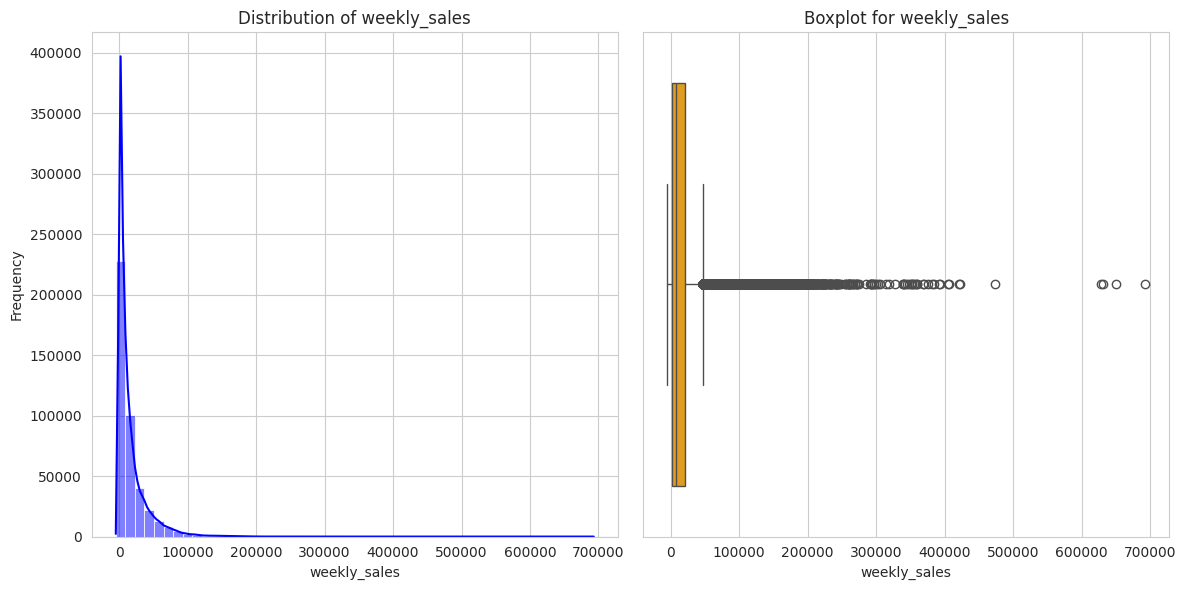

skewness: 3.26
kurtosis: 21.49
min: -4988.94
max: 693099.36


In [45]:

histogram_box_subplot(df, col='weekly_sales', bins=50, color_hist='blue', color_box='orange')
stats = skew_stats(df, col='weekly_sales')
for key, value in stats.items():
    print(f"{key}: {value}")


### Univariate Analysis of Other Variables

In [47]:
numeric_cols = ['temperature', 'cpi', 'unemployment', 'fuel_price', 'size', 'total_markdown']

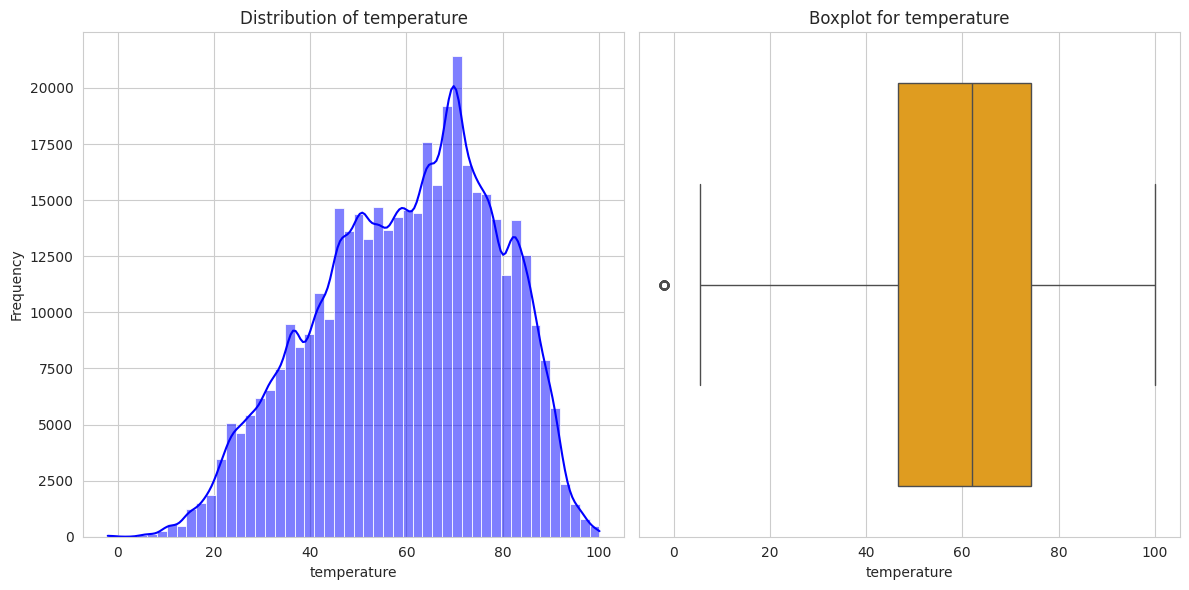

skewness: -0.3199999928474426
kurtosis: -0.6399999856948853
min: -2.059999942779541
max: 100.13999938964844


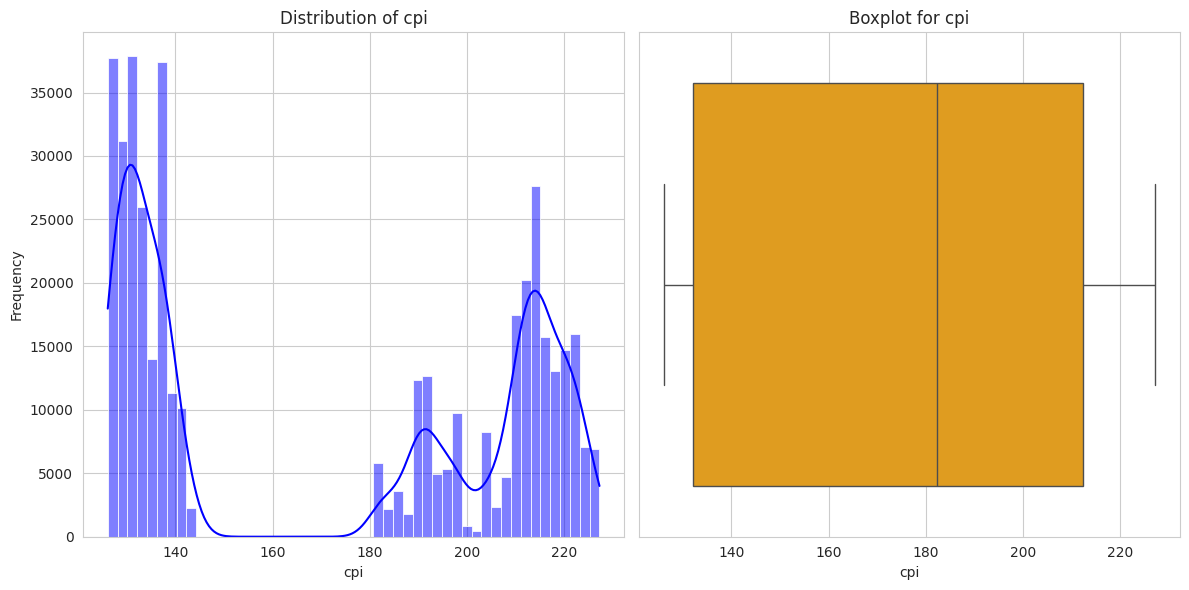

skewness: 0.09000000357627869
kurtosis: -1.8300000429153442
min: 126.06400299072266
max: 227.23280334472656


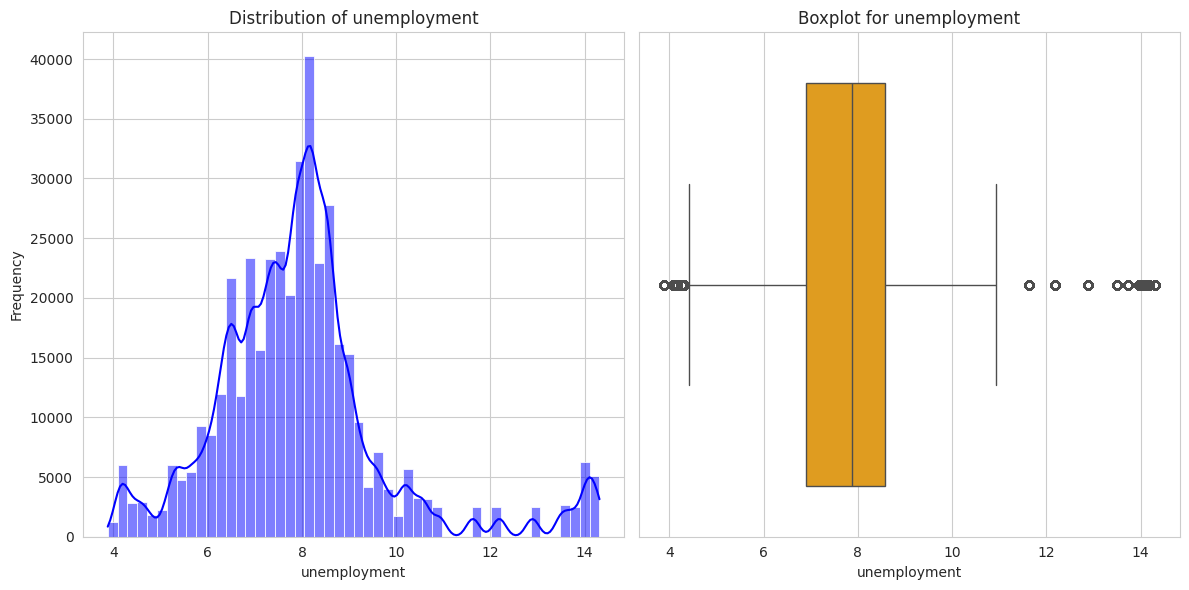

skewness: 1.1799999475479126
kurtosis: 2.7300000190734863
min: 3.878999948501587
max: 14.312999725341797


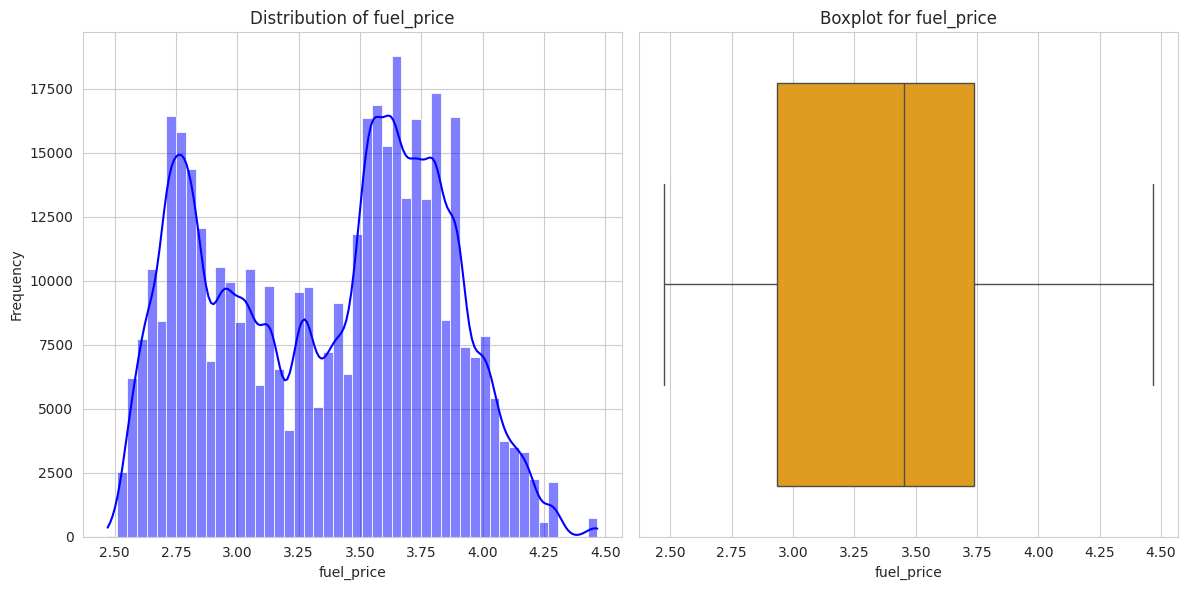

skewness: -0.10000000149011612
kurtosis: -1.190000057220459
min: 2.4719998836517334
max: 4.4679999351501465


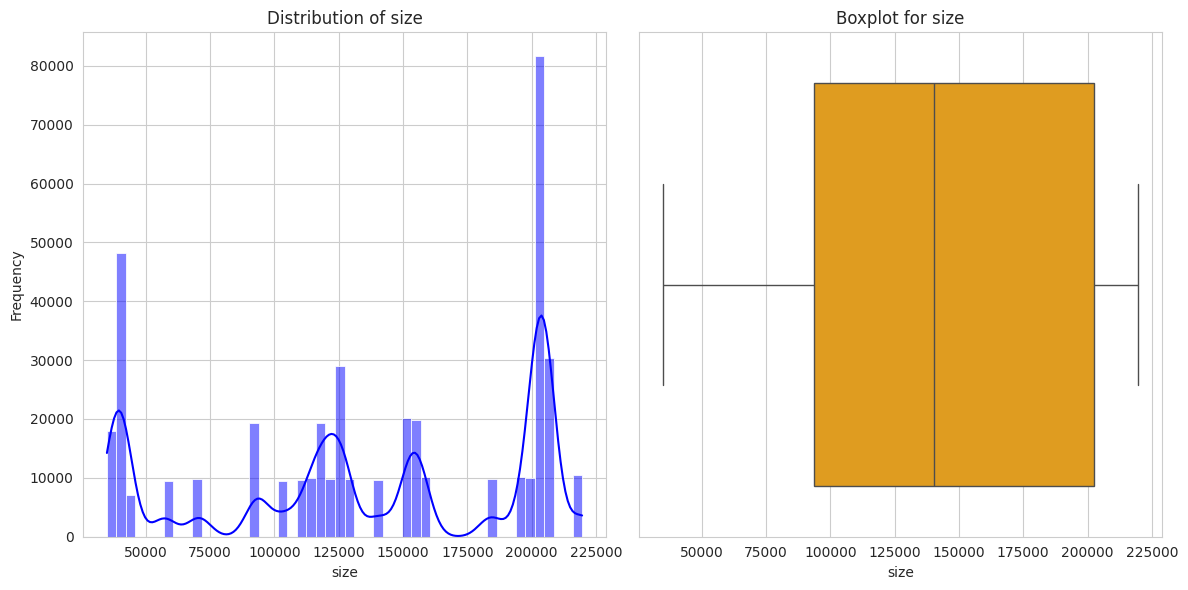

skewness: -0.33
kurtosis: -1.21
min: 34875
max: 219622


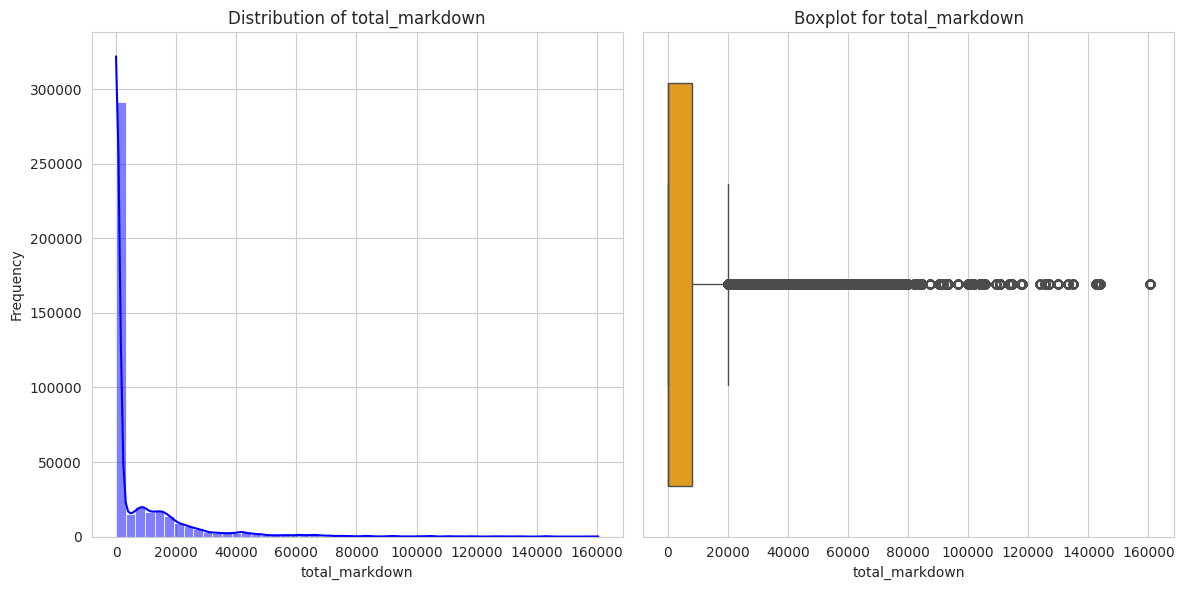

skewness: 3.89
kurtosis: 20.9
min: 0.0
max: 160510.61000000002


In [48]:
for col in numeric_cols:
    histogram_box_subplot(df, col=col, bins=50, color_hist='blue', color_box='orange')
    stats = skew_stats(df, col=col)
    for key, value in stats.items():
        print(f"{key}: {value}")


#### Univariate Analysis Insights

#### 1. Target Variable (`Weekly_Sales`)

* **Distribution:** Highly **Right-Skewed (3.26)**. The vast majority of weekly sales are "average," but the business is driven by extreme "Blockbuster Weeks" (Holidays).
* **Volatility:** Extreme **Kurtosis (21.49)**. This indicates "Fat Tails"—unexpectedly massive sales events happen far more frequently than a normal statistical model would predict.
* **Data Integrity:** Presence of **negative values** (Min: -4,988) confirms that returns are recorded as negative sales.
* **Strategy:** These should likely be clipped to 0 for demand forecasting models.

---

##### 2. Independent Features (The Drivers)

##### **CPI (Consumer Price Index)**

* **Pattern:** Trimodal Distribution.
* **Insight:** Stores are clearly divided into three distinct economic zones:
1. **Low CPI (~130):** Rural or lower-cost-of-living regions.
2. **Medium CPI (~190):** Likely in suburban areas.
3. **High CPI (~210):** Urban or high-cost-of-living regions.


* **Strategy:** "Economic Zone" could be a powerful segmentation feature.

##### **Unemployment**

* **Pattern:** Right-Skewed with a long tail.
* **Insight:** Most stores operate in healthy economies (~7-8% unemployment), but a cluster of "Distressed Stores" exists in areas with **>10% unemployment**. These outliers may require a separate strategy.

##### **Fuel Price**

* **Pattern:** Multi-modal / Choppy.
* **Insight:** This is likely a **Time Artifact** (prices were distinctively lower in 2010 vs. 2012) rather than a purely store-based difference.

##### **Store Size (Correction)**

* **Initial Thought:** Trimodal (Small, Medium, Large).
* **Refined Observation:** A distinct spike around **160k sq ft** suggests a 4th store prototype.
* **Action:** We will refine `store_size_cat` from 3 bins to **4 Bins** (Small, Medium, Large, Super-Large) to capture this nuance.

##### **Total Markdown (Promotional Discount)**

* **Observation:** The plot suggests that most of the time the promotional offers were **None (0)**. However, there were certain times when huge promotional discounts were offered, likely during holidays or festivals where sales are very high.

### Correlations between variables

In [49]:
numeric_cols = ['weekly_sales', 'temperature', 'total_markdown', 'cpi', 'unemployment', 'fuel_price', 'size']

In [50]:
corr_matrix = df[numeric_cols].corr()
corr_matrix


,weekly_sales,temperature,total_markdown,cpi,unemployment,fuel_price,size
weekly_sales,1.000000,-0.002312,0.065237,-0.020921,-0.025864,-0.000120,0.243828
temperature,-0.002312,1.000000,-0.111253,0.182112,0.096730,0.143859,-0.058313
total_markdown,0.065237,-0.111253,1.000000,0.019894,-0.118753,0.244348,0.186552
cpi,-0.020921,0.182112,0.019894,1.000000,-0.299953,-0.164210,-0.003314
unemployment,-0.025864,0.096730,-0.118753,-0.299953,1.000000,-0.033853,-0.068238
fuel_price,-0.000120,0.143859,0.244348,-0.164210,-0.033853,1.000000,0.003361
size,0.243828,-0.058313,0.186552,-0.003314,-0.068238,0.003361,1.000000


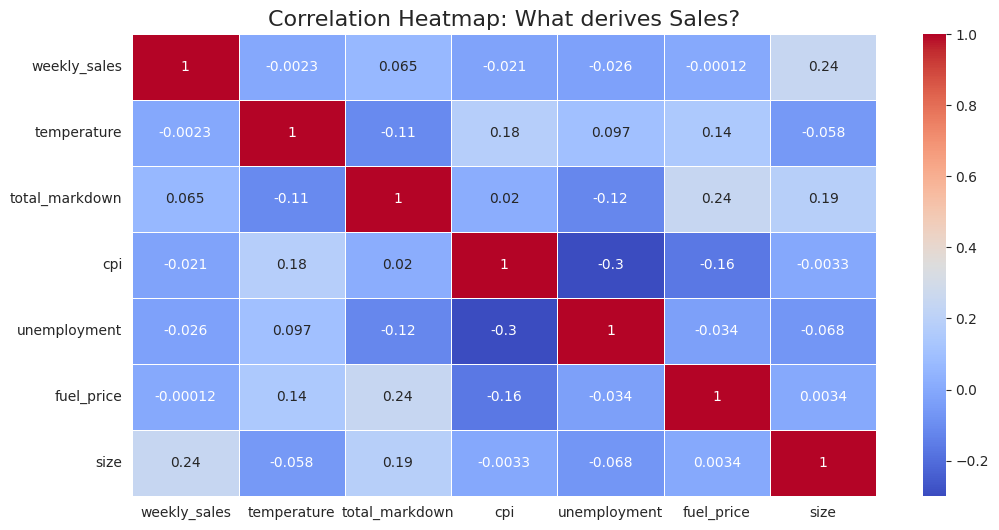

In [51]:
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Correlation Heatmap: What derives Sales?', fontsize=16)
plt.show()

#### 1. Key Drivers of Sales (Linear Relationships)

##### **Store Size**

* **Observation:** This is the strongest positive correlation in the dataset.
* **Insight:** Physical capacity is a primary cap on revenue. Larger stores (Supercenters) consistently generate higher weekly sales than smaller neighborhood markets. This validates the need to treat `Store_Size_Cat` as a critical feature for the model.

##### **Promotional Impact**

* **Observation:** `Total_MarkDown` shows a positive but weak correlation.
* **Insight:** While positive, the low value suggests that promotions are **event-driven**, not constant. A simple linear correlation dilutes their impact because most weeks have low/zero markdowns. The *lift* from promotions likely happens in short, sharp bursts (e.g., Super Bowl week) rather than a smooth linear trend.

---

#### 2. Weak or Non-Linear Factors

##### **Unemployment**

* **Observation:** Negligible negative correlation.
* **Insight:** Economic downturns do not significantly reduce revenue for this retailer. As a provider of essentials (groceries/basics), the business is "Recession-Resistant." High unemployment regions do not automatically equal low sales.

##### **Fuel Price**

* **Observation:** Zero correlation.
* **Insight:** Changes in fuel costs have **no direct linear impact** on weekly sales volume. Customers absorb these costs rather than cutting back on essential shopping.

#### **CPI**

* **Observation:** Very weak negative correlation.
* **Critical Note:** This low number is deceptive. Our Univariate Analysis (Histogram) proved CPI has **three distinct clusters**. A linear correlation tries to draw a straight line through three separate "clouds" of data, failing to capture the structural difference between "Rural" and "Urban" store performance.

### Numerical Bivariate Analysis

#### Store Size vs Sales

- Histogram suggested quardmodal distribution i.e 4 different standard sizes which were most common.
- we can verify the clusters using a scatter plot 

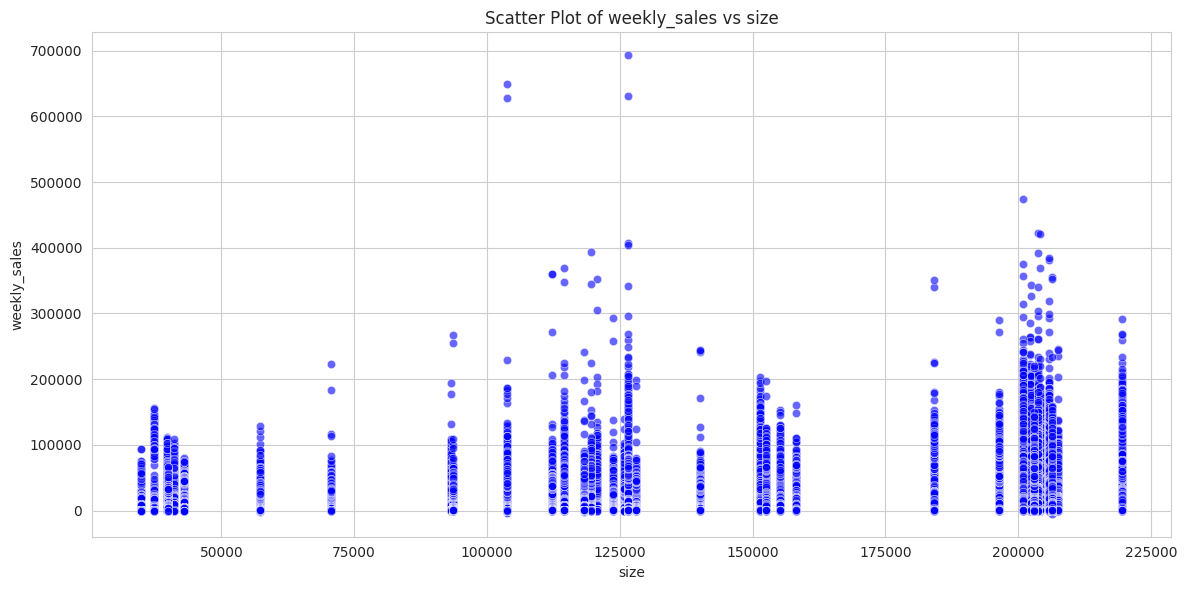

In [52]:
scatter_plot(df, x_col='size', y_col='weekly_sales')

#### CPI vs Sales 
- We found in  histogram that CPI has three distinct clusters which are basically CPI for rural and urban stores.
- We can confirm that pattern with scatter plot between CPI and Sales

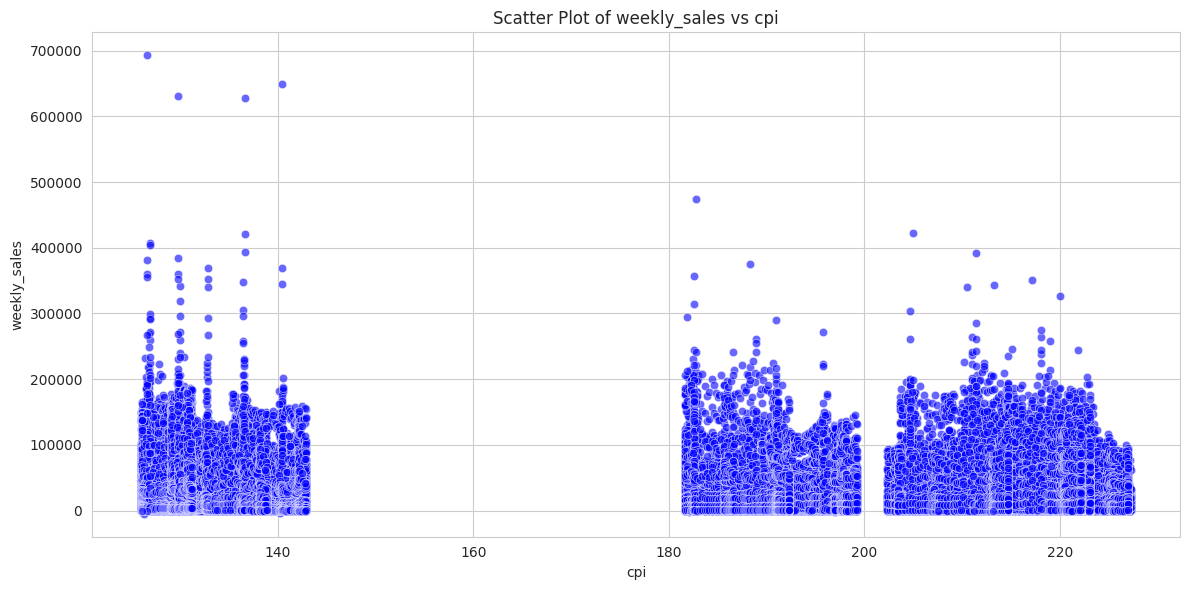

In [53]:
scatter_plot(df, x_col='cpi', y_col='weekly_sales')

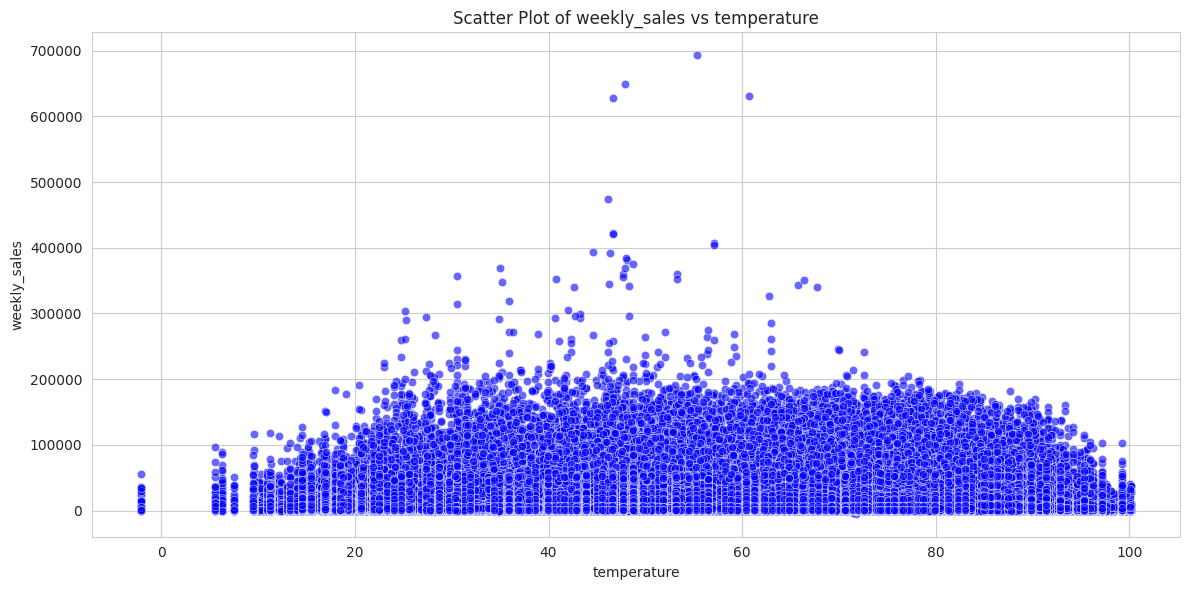

In [54]:
scatter_plot(df, x_col='temperature', y_col='weekly_sales')

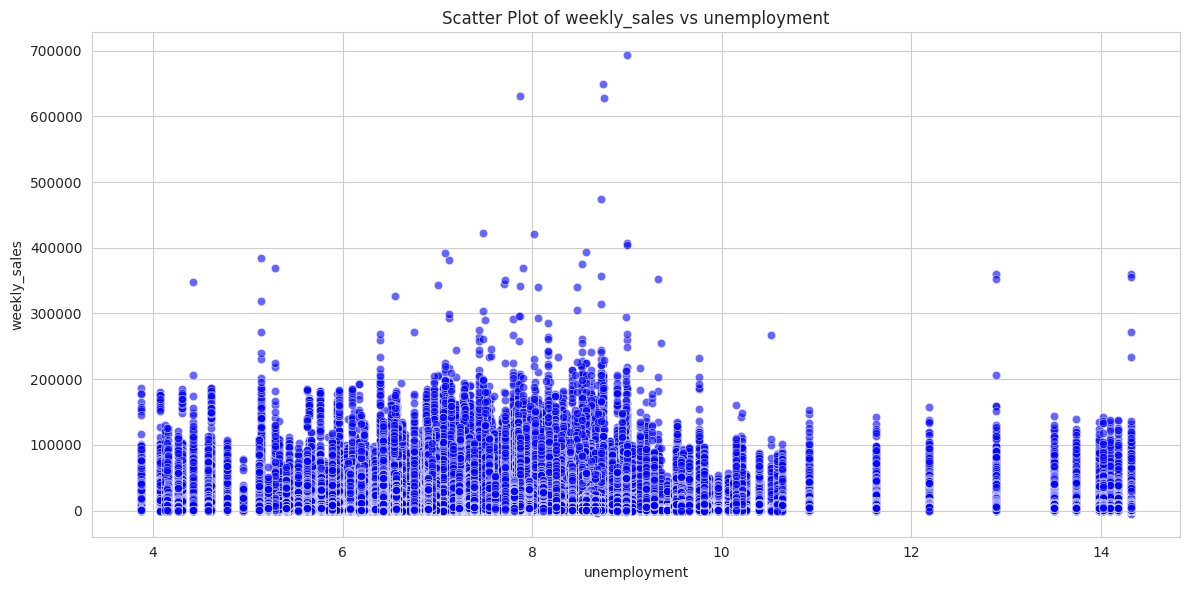

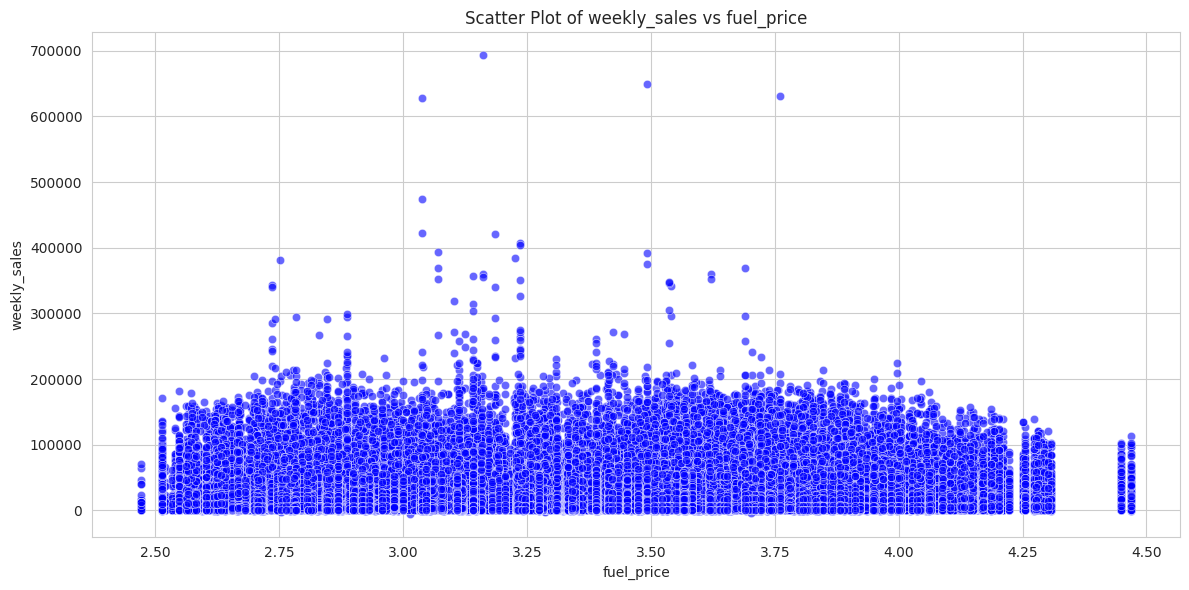

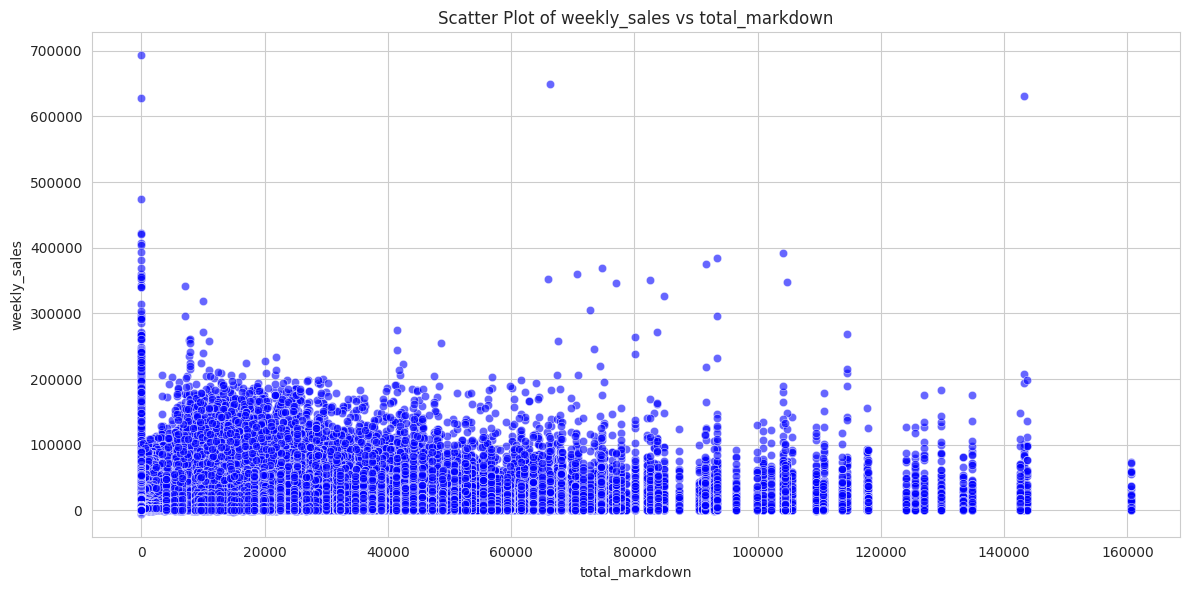

In [55]:
scatter_plot(df, x_col='unemployment', y_col='weekly_sales')
scatter_plot(df, x_col='fuel_price', y_col='weekly_sales')
scatter_plot(df, x_col='total_markdown', y_col='weekly_sales')

### Categorical Bivariate Analysis

In [56]:
def boxplot_cat(df:pd.DataFrame, ax , cat_col: str, target_col: str, color='blue'):
    """
    Create a boxplot for a categorical column against a target column.

    Parameters:
    - df: The input DataFrame.
    - ax: The matplotlib Axes object where the plot will be drawn.
    - cat_col: The categorical column name.
    - target_col: The target column name.
    - color: The color for the boxplot (default is 'orange').
    """
    sns.set_style('white')
    sns.boxplot(x=cat_col, y=target_col, data=df, ax=ax, color=color)
    ax.set_title(f'Boxplot of {target_col} by {cat_col}')
    ax.set_xlabel(cat_col)
    ax.set_ylabel(target_col)

    return

In [57]:
df.columns


Index(['store', 'dept', 'date', 'weekly_sales', 'year', 'month', 'season',
       'isholiday', 'type', 'size', 'store_size_cat', 'temperature',
       'temp_range', 'fuel_price', 'cpi', 'unemployment', 'markdown1',
       'markdown2', 'markdown3', 'markdown4', 'markdown5', 'total_markdown',
       'has_promo'],
      dtype='object')

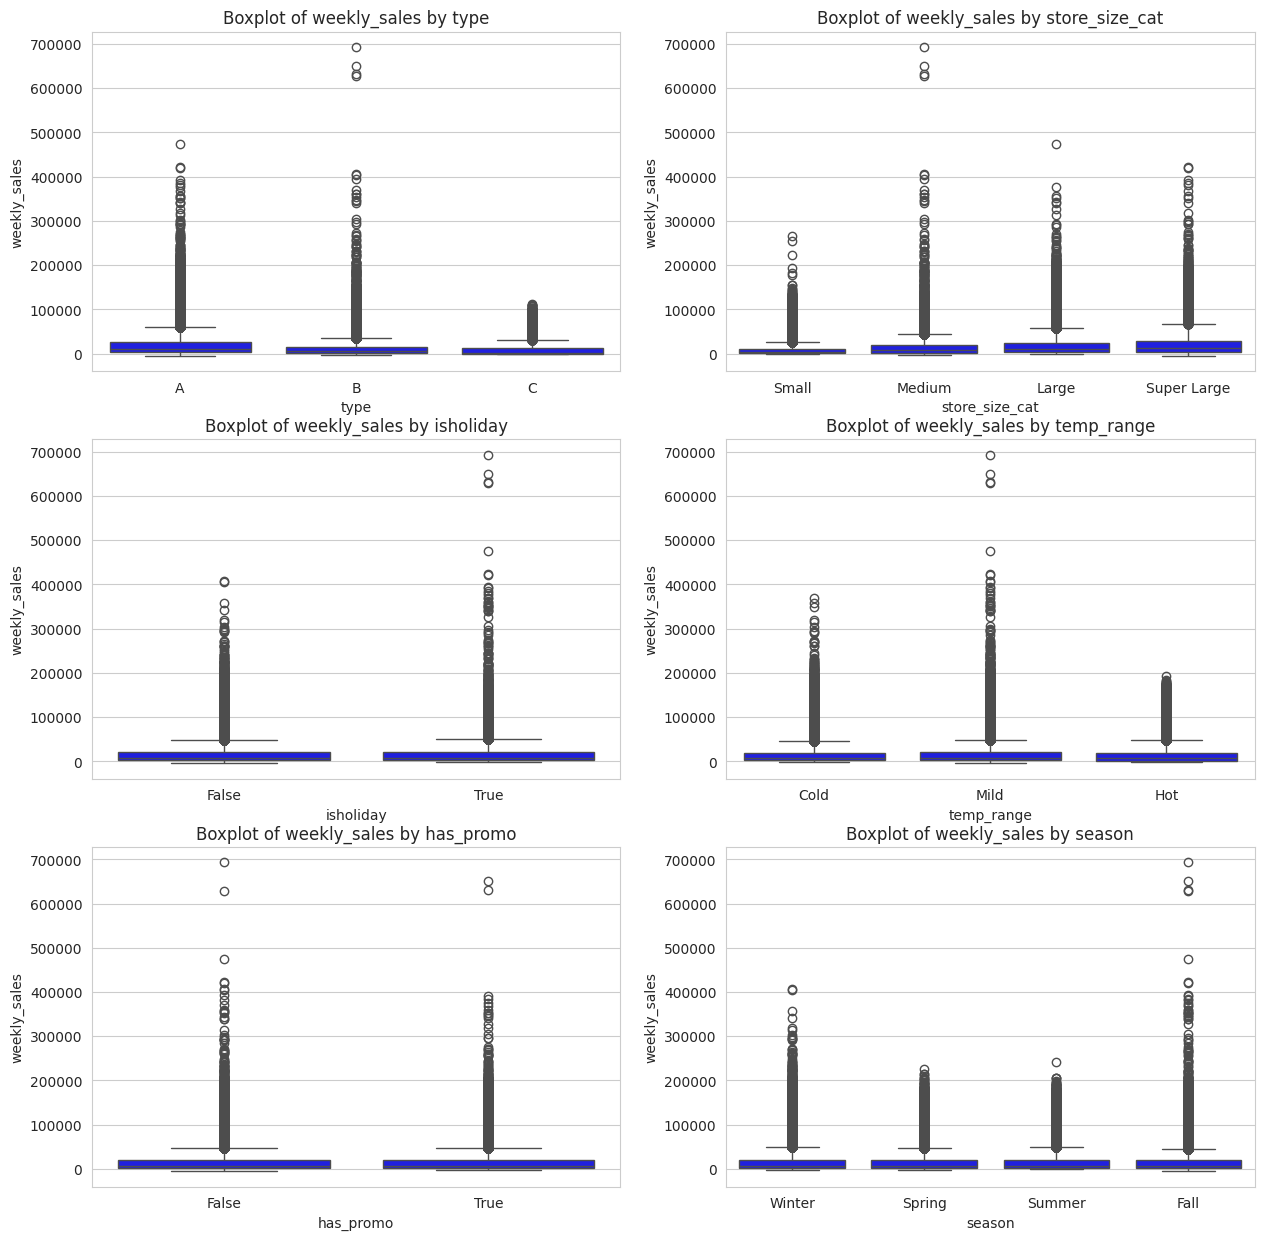

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

boxplot_cat(df, axes[0, 0], cat_col='type', target_col='weekly_sales')
boxplot_cat(df, axes[0, 1], cat_col='store_size_cat', target_col='weekly_sales')
boxplot_cat(df, axes[1, 0], cat_col='isholiday', target_col='weekly_sales')
boxplot_cat(df, axes[1, 1], cat_col='temp_range', target_col='weekly_sales')
boxplot_cat(df, axes[2, 0], cat_col='has_promo', target_col='weekly_sales')
boxplot_cat(df, axes[2, 1], cat_col='season', target_col='weekly_sales')
# fig.delaxes(axes[2, 1])


#### EDA Phase 3: Categorical Driver Analysis

#### 1. Store Type & Size Impact

* **Store Type Performance:**
* **Observation:** "Type A" stores show the highest median sales and the largest interquartile range (IQR). "Type C" stores are significantly smaller in volume with tighter variance.
* **Insight:** Store Type is a massive discriminator. "Type A" likely represents Supercenters, while "Type C" represents smaller neighborhood formats. This confirms that **Store Type** must be a primary feature in our predictive model.


* **Store Size (4-Bin Validation):**
* **Observation:** The box plot confirms a clear "Step-Function" increase in sales as we move from `Small`  `Medium`  `Large`  `Super-Large`.
* **Validation:** The distinct performance gap between "Large" and "Super-Large" validates our decision to split size into 4 bins instead of 3. Merging them would have obscured the higher performance ceiling of the largest stores.



#### 2. Temporal Factors (Time & Season)

* **The "Holiday Paradox":**
* **Observation:** Surprisingly, the *median* sales for Holidays (`IsHoliday=True`) are not drastically higher than non-holidays. However, the **Outliers (Upper Whiskers)** for holidays are massive.
* **Insight:** Holidays don't raise the "floor" of sales; they raise the "ceiling." This means holidays are **high-variance events**. We cannot just predict "higher sales"; we must predict "potential for extreme spikes."


* **Seasonal Trends:**
* **Observation:** **Winter** shows the highest volatility and extreme upper outliers.
* **Insight:** This aligns with the retail calendar (Thanksgiving + Christmas). While Spring and Summer are stable, Winter is the "Make or Break" season where inventory management is most critical.



### Trivariate Analysis

#### Stores AND Department Analysis

In [59]:
# 1. Ranking Stores
# We aggregate by 'store' to calculate both Total (sum) and Efficiency (mean).
store_stats = df.groupby('store').agg({
    'weekly_sales': ['sum', 'mean'],
    'size': 'mean', 
    'type': 'first'
}).reset_index()

# Flatten the multi-level column names created by agg
store_stats.columns = ['store', 'total_sales', 'avg_weekly_sales', 'size', 'type']

top_stores_total = store_stats.sort_values(by='total_sales', ascending = False).head(20)

In [60]:
top_stores_total

,store,total_sales,avg_weekly_sales,size,type
19,20,3.013978e+08,29508.301592,203742.0,A
3,4,2.995440e+08,29161.210415,205863.0,A
13,14,2.889999e+08,28784.851727,200898.0,A
12,13,2.865177e+08,27355.136891,219622.0,A
1,2,2.753824e+08,26898.070031,202307.0,A
9,10,2.716177e+08,26332.303819,126512.0,B
26,27,2.538559e+08,24826.984536,204184.0,A
5,6,2.237561e+08,21913.243624,202505.0,A
0,1,2.224028e+08,21710.543621,151315.0,A
38,39,2.074455e+08,21000.763562,184109.0,A


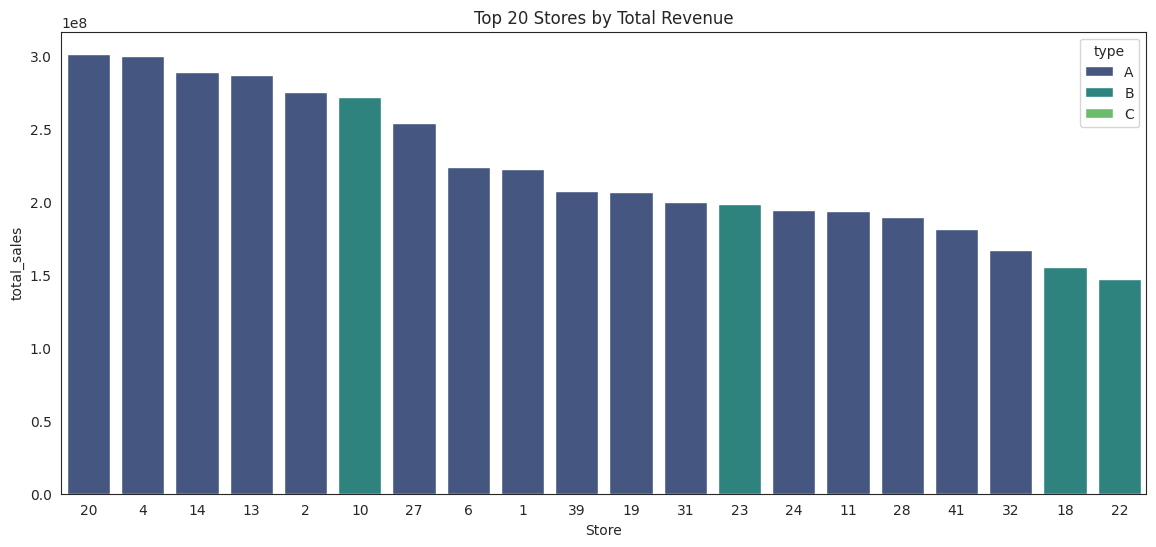

In [61]:
# Visualization
plt.figure(figsize=(14, 6))
sns.barplot(data=top_stores_total, x='store', y='total_sales', hue='type', order=top_stores_total['store'], palette='viridis')
plt.title('Top 20 Stores by Total Revenue')
plt.xlabel('Store')
plt.show()

Seasonal Sales by Stores

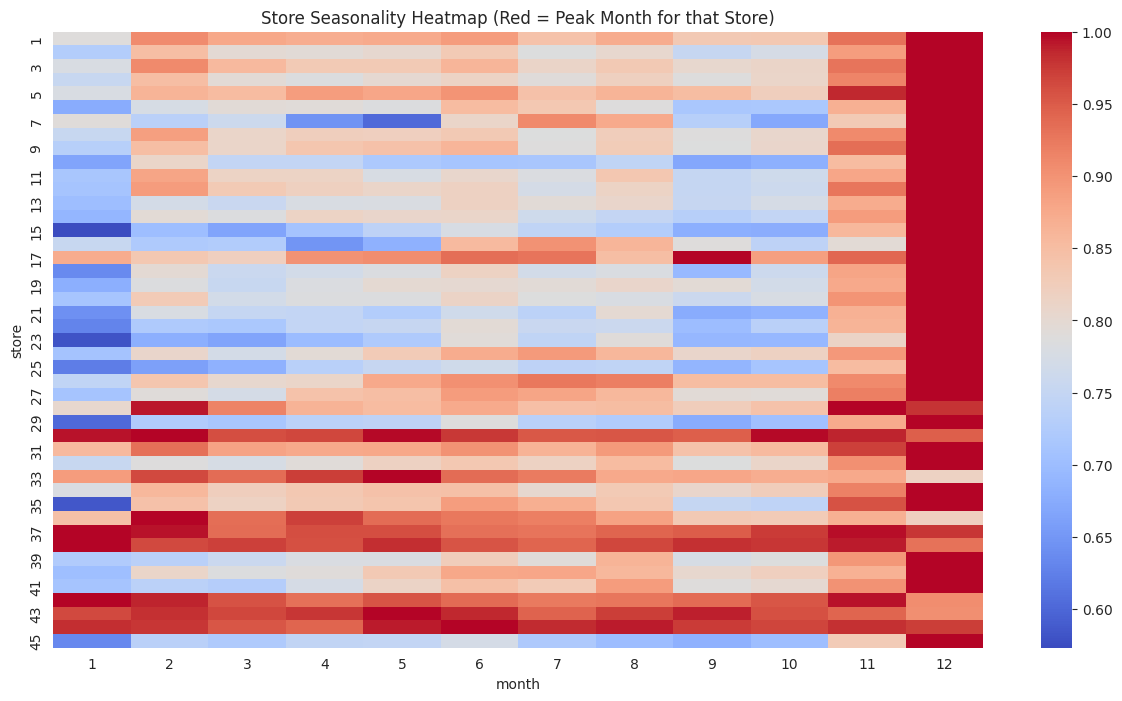

In [62]:
# Pivot: Rows=Store, Cols=Month, Values=Average Sales
pivot_store = df.groupby(['store', 'month'])['weekly_sales'].mean().unstack()

# Normalization (The Critical Step)
# Divide each row by its maximum value. 
# Result: 1.0 = Peak Month, 0.5 = Half of Peak.
pivot_store_norm = pivot_store.div(pivot_store.max(axis=1), axis=0)

# Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_store_norm, cmap='coolwarm', linewidths=0.0)
plt.title('Store Seasonality Heatmap (Red = Peak Month for that Store)')
plt.show()

Store Seasonality Heatmap
The Theory: Row-Wise Normalization
The Problem: Store 20 sells $2M/week. Store 33 sells $200k/week. If we plot them on a heatmap, Store 20 will be "Red Hot" and Store 33 will be "Blue Cold" everywhere. We won't see when Store 33 peaks.

The Solution: Normalization. We scale each store's sales from 0 to 1 (where 1 = That specific store's busiest month).

Why: This reveals the Pulse of the fleet. Do all stores peak in December? Or do "Beach Stores" peak in July?

Insights Found
Uniformity: Almost every single store turns Red (Peak) in Month 12 (December).

Strategic Implication: This confirms that the business is universally driven by the Winter Holidays. There are no major "Counter-Seasonal" stores (e.g., stores that peak in Summer only). Supply chain planning can be synchronized across the entire fleet.

#### Store Size vs Sales vs Type

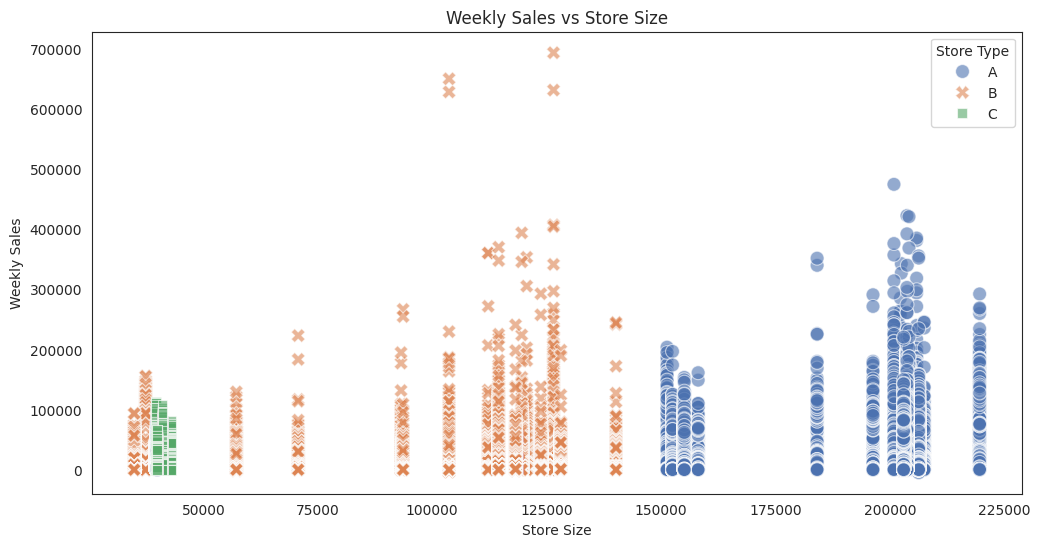

In [63]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='size', y='weekly_sales', hue='type', style='type', alpha=0.6, palette='deep', s=100)
plt.title('Weekly Sales vs Store Size')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.legend(title='Store Type')
plt.show()

#### Department Wise Sales

In [64]:
dept_sales = df.groupby('dept').agg({'weekly_sales': ['sum', 'mean'], 'size': ['mean'], 'type': ['first'], 'store_size_cat': ['first']}).reset_index()

dept_sales.columns = ['dept', 'total_sales', 'avg_weekly_sales', 'avg_store_size', 'store_type', 'store_size_cat']

top_departments = dept_sales.sort_values(by='total_sales', ascending=False).head(20)


In [65]:
df.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'year', 'month', 'season',
       'isholiday', 'type', 'size', 'store_size_cat', 'temperature',
       'temp_range', 'fuel_price', 'cpi', 'unemployment', 'markdown1',
       'markdown2', 'markdown3', 'markdown4', 'markdown5', 'total_markdown',
       'has_promo'],
      dtype='object')

In [72]:
df['dept'].nunique()

81

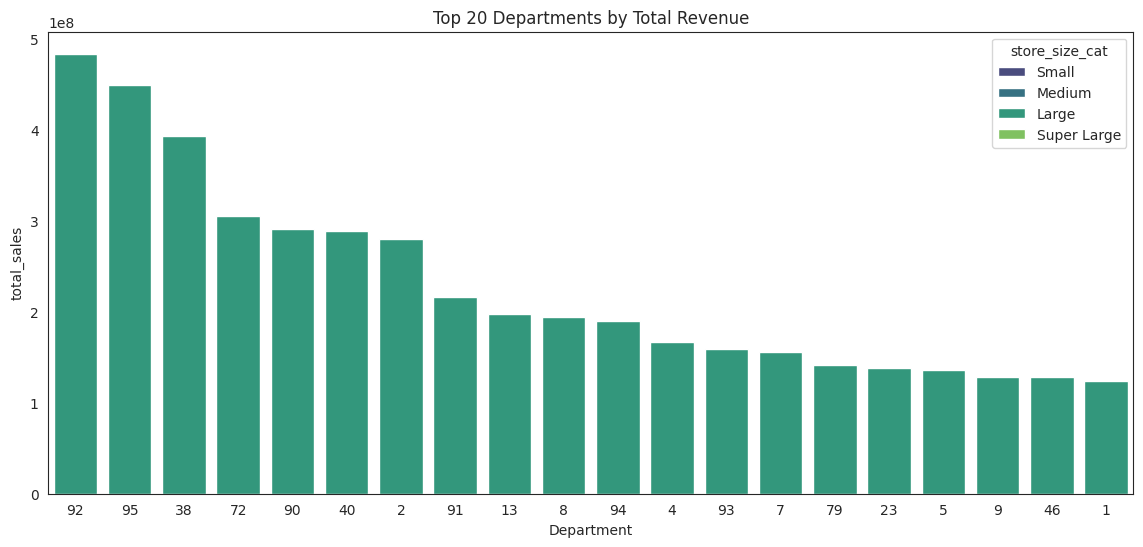

In [66]:
# Visualization
plt.figure(figsize=(14, 6))
sns.barplot(data=top_departments, x='dept', y='total_sales', hue='store_size_cat', order=top_departments['dept'], palette='viridis')
plt.title('Top 20 Departments by Total Revenue')
plt.xlabel('Department')
plt.show()

In [73]:
dept_sales

,dept,total_sales,avg_weekly_sales,avg_store_size,store_type,store_size_cat
0,1,1.236388e+08,19213.485088,130287.600000,A,Large
1,2,2.806112e+08,43607.020113,130287.600000,A,Large
2,3,7.589245e+07,11793.698516,130287.600000,A,Large
3,4,1.671467e+08,25974.630238,130287.600000,A,Large
4,5,1.356074e+08,21365.583515,131530.357964,A,Large
...,...,...,...,...,...,...
76,95,4.493202e+08,69824.423080,130287.600000,A,Large
77,96,7.383392e+07,15210.942761,129282.010507,A,Large
78,97,8.949651e+07,14255.576919,130676.377190,A,Large
79,98,3.982892e+07,6824.694889,135266.091501,A,Large


In [94]:
sorted_dept_sales = dept_sales.sort_values(by='total_sales', ascending=False)

sorted_dept_sales['cumulative_pct'] = (sorted_dept_sales['total_sales'].cumsum() / sorted_dept_sales['total_sales'].sum())*100
sorted_dept_sales['category'] = sorted_dept_sales['cumulative_pct'].apply(lambda x: 'Top 80% Revenue' if x <= 80 else 'Bottom 20% Revenue')
sorted_dept_sales

,dept,total_sales,avg_weekly_sales,avg_store_size,store_type,store_size_cat,cumulative_pct,category
73,92,4.839433e+08,75204.870531,130287.600000,A,Large,7.183132,Top 80% Revenue
76,95,4.493202e+08,69824.423080,130287.600000,A,Large,13.852355,Top 80% Revenue
36,38,3.931181e+08,61090.619568,130287.600000,A,Large,19.687376,Top 80% Revenue
60,72,3.057252e+08,50566.515417,136110.398611,A,Large,24.225230,Top 80% Revenue
71,90,2.910685e+08,45232.084488,130287.600000,A,Large,28.545536,Top 80% Revenue
...,...,...,...,...,...,...,...,...
49,51,3.057283e+04,21.931729,148082.084648,A,Large,100.000045,Bottom 20% Revenue
63,78,1.714710e+03,7.296638,161519.463830,A,Large,100.000071,Bottom 20% Revenue
37,39,1.779800e+02,11.123750,198393.687500,A,Large,100.000073,Bottom 20% Revenue
41,43,1.432000e+01,1.193333,136868.833333,A,Super Large,100.000074,Bottom 20% Revenue


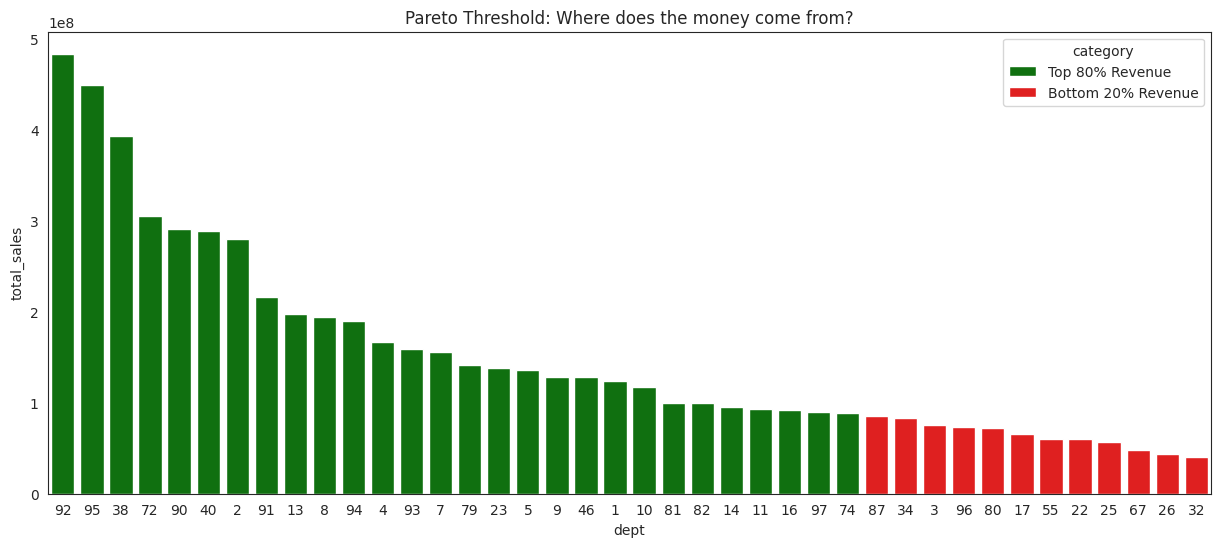

In [95]:
plt.figure(figsize=(15,6))

sns.barplot(data=sorted_dept_sales.head(40),
             x='dept',
             y='total_sales', hue='category',
             palette={'Top 80% Revenue':'green', 'Bottom 20% Revenue':'red'},
             order=sorted_dept_sales['dept'].head(40),
             dodge=False)
plt.title('Pareto Threshold: Where does the money come from?')
plt.show()

Seasonal Sales By Department

In [68]:
df.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'year', 'month', 'season',
       'isholiday', 'type', 'size', 'store_size_cat', 'temperature',
       'temp_range', 'fuel_price', 'cpi', 'unemployment', 'markdown1',
       'markdown2', 'markdown3', 'markdown4', 'markdown5', 'total_markdown',
       'has_promo'],
      dtype='object')

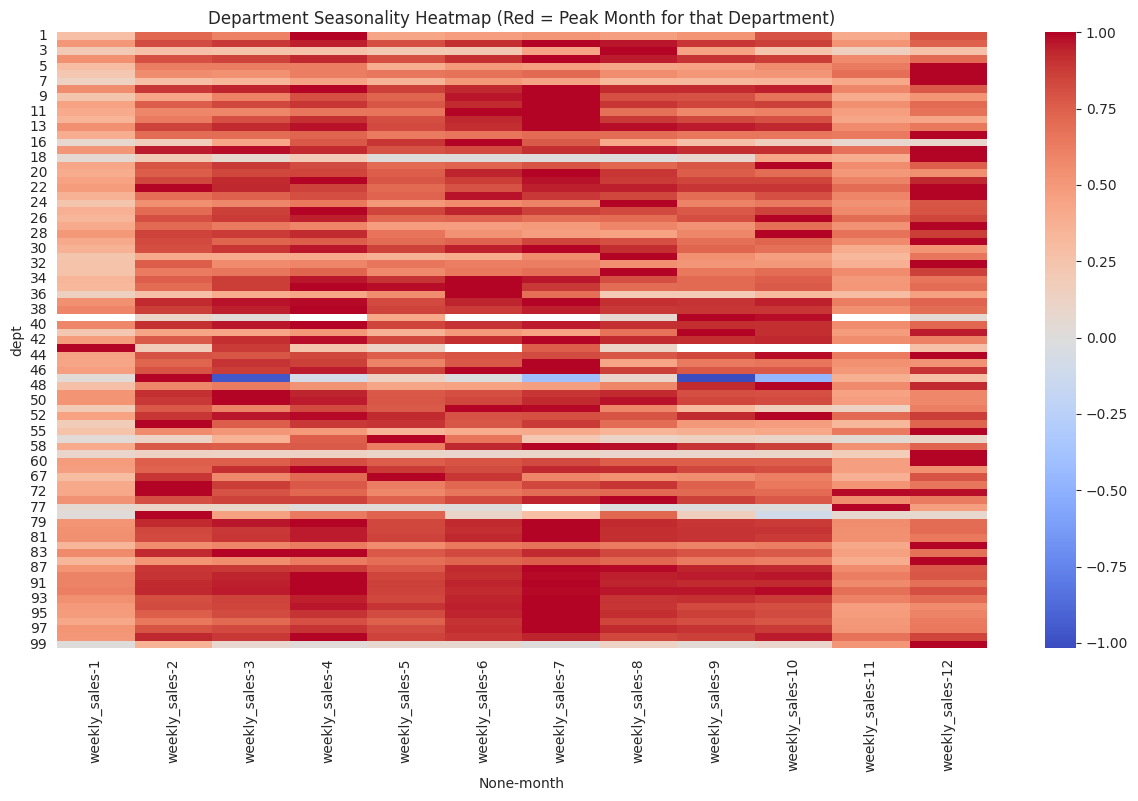

In [69]:
seasonal_dept = df.groupby(['dept', 'month']).agg({'weekly_sales': 'sum'}).unstack()

seasonal_dept_norm = seasonal_dept.div(seasonal_dept.max(axis=1), axis=0)

# Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(seasonal_dept_norm, cmap='coolwarm', linewidths=0.0)
plt.title('Department Seasonality Heatmap (Red = Peak Month for that Department)')
plt.show()
